# EUbOPEN → AnnData

Builds an AnnData object from the [Cell Painting dataset of EUbOPEN compounds](https://zenodo.org/records/10894238) (Sumia, Servier R&D Institute Paris-Saclay, CC-BY-4.0).
One observation is a well, one variable is a CellProfiler feature.

U2OS cells, 8 doses on 105 plates across four runs, distributed as a single 2.3 GB parquet file:

```bash
curl -L -o hcs_cellpainting_eubopen.parquet \
  "https://zenodo.org/api/records/10894238/files/hcs_cellpainting_eubopen(1).parquet/content"
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/2024_EUbOPEN_CellPainting/hcs_cellpainting_eubopen.parquet").expanduser()

## Missing values are encoded as -9999

This dataset contains no NaN.
Missing measurements are written as the sentinel `-9999`, which would otherwise enter the matrix as a real value and dominate any distance computation.
The sentinel differs between datasets, so `read_profiles` takes it as a parameter rather than assuming one.

Metadata columns are prefixed `meta_` or `metadata_` here, against `Metadata_` in CPJUMP1; both are recognised by default.

In [2]:
adata = cpio.read_profiles(PROFILES, sentinels=-9999, index_columns=("id_plate", "id_well"))

missing = np.isnan(adata.X)
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"missing: {missing.sum():,} values ({missing.mean():.1%})")
print(f"features with any missing: {(missing.any(axis=0)).sum():,}")
print(f"features entirely missing: {(missing.all(axis=0)).sum():,}")

39,206 wells x 7,703 features
missing: 72,554,330 values (24.0%)
features with any missing: 2,760
features entirely missing: 1,064


## Case-duplicated columns

55 features appear twice, differing only in capitalisation, for example `Nuclei_Correlation_Manders_AGP_DNA` and `nuclei_correlation_manders_agp_dna`.
The pairs are not copies: the capitalised member is sentinel-filled where the lower-case one holds real values.

In [3]:
lowercased = pd.Index([name.lower() for name in adata.var_names])
print(f"case-duplicated feature names: {int(lowercased.duplicated().sum())}")

case-duplicated feature names: 55


Keeping only features that are complete resolves both problems at once, since every capitalised duplicate is sentinel-contaminated.

In [4]:
adata = cpio.drop_incomplete_features(adata)
lowercased = pd.Index([name.lower() for name in adata.var_names])
print(f"{adata.n_vars:,} complete features, {int(lowercased.duplicated().sum())} case-duplicates remaining")

4,943 complete features, 0 case-duplicates remaining


## Annotation

The same name grammar as CPJUMP1, lower-cased and with the channel last rather than mid-name, so the shared parser handles both.
`image` joins `cells`, `cytoplasm` and `nuclei` as a compartment: these are whole-image measurements not tied to a segmented object.

In [5]:
cpio.annotate_features(adata.var)
cpio.categorize(adata, ["id_plate", "id_batch", "perturbator_type", "control_type", "concentration_unit"])
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
image_granularity_10_agp,image,granularity,agp,NaN,1
image_granularity_10_bfhigh,image,granularity,brightfield_high,NaN,1
image_granularity_10_bflow,image,granularity,brightfield_low,NaN,1
image_granularity_10_brightfield,image,granularity,brightfield,NaN,1
image_granularity_10_dna,image,granularity,dna,NaN,1
...,...,...,...,...,...
nuclei_texture_variance_rna_3_03_256,nuclei,texture,rna,NaN,1
nuclei_texture_variance_rna_5_00_256,nuclei,texture,rna,NaN,1
nuclei_texture_variance_rna_5_01_256,nuclei,texture,rna,NaN,1


In [6]:
adata.var.value_counts(["compartment", "n_channels"]).unstack(fill_value=0)

n_channels,1,0,2
compartment,,,
cells,1131,31,124
cytoplasm,1077,21,122
image,1126,73,0
nuclei,1130,29,79


## Sanity checks

In [7]:
print(f"plates: {adata.obs['id_plate'].nunique()} | runs: {adata.obs['id_batch'].nunique()}")
print(f"perturbagen ids: {adata.obs['id_perturbator'].nunique()} (Zenodo advertises 595 compounds)")
print(f"non-finite values: {int((~np.isfinite(adata.X)).sum())}")
print(adata.obs.groupby("perturbator_type", observed=True)["control_type"].value_counts(dropna=False))

plates: 105 | runs: 4
perturbagen ids: 575 (Zenodo advertises 595 compounds)
non-finite values: 0
perturbator_type  control_type
control           poscon           3769
                  negcon           3715
                  nan                 0
trt               nan             31722
                  poscon              0
                  negcon              0
Name: count, dtype: int64


The treated wells carry nine distinct concentrations, but two of them are the same dose written at different precision.

In [8]:
sorted(adata.obs.loc[adata.obs["perturbator_type"] == "trt", "concentration"].unique())

[np.float64(3.125e-06),
 np.float64(1e-05),
 np.float64(3.125e-05),
 np.float64(3.13e-05),
 np.float64(0.0001),
 np.float64(0.0003125),
 np.float64(0.001),
 np.float64(0.003125),
 np.float64(0.01)]

In [9]:
adata.write_h5ad(PROFILES.with_name("eubopen.h5ad"))

## UMAP

Unlike the CPJUMP1 profiles, these are not pycytominer-normalized: feature standard deviations span 0.99 to 208, so a handful of features would otherwise dominate the principal components.
They are scaled before PCA.

In [10]:
sc.pp.scale(adata, max_value=10)
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


As with CPJUMP1, measure the structure before reading anything off the embedding.

In [11]:
cpio.neighbour_enrichment(adata, ["id_plate", "id_batch", "perturbator_type", "concentration"])

,observed,baseline,ratio
covariate,,,
id_plate,0.182,0.010,18.939
id_batch,0.632,0.283,2.234
perturbator_type,0.805,0.691,1.165
concentration,0.367,0.132,2.772


Plate dominates, an order of magnitude above its baseline and far beyond anything biological — a stronger plate effect than CPJUMP1 shows.
Dose comes next, ahead of run, while treated-versus-control is barely above chance.
That ordering is the expected one for a dose-response screen: most wells sit at concentrations too low to produce a phenotype, so simply being treated says little, whereas the top doses do move cells.

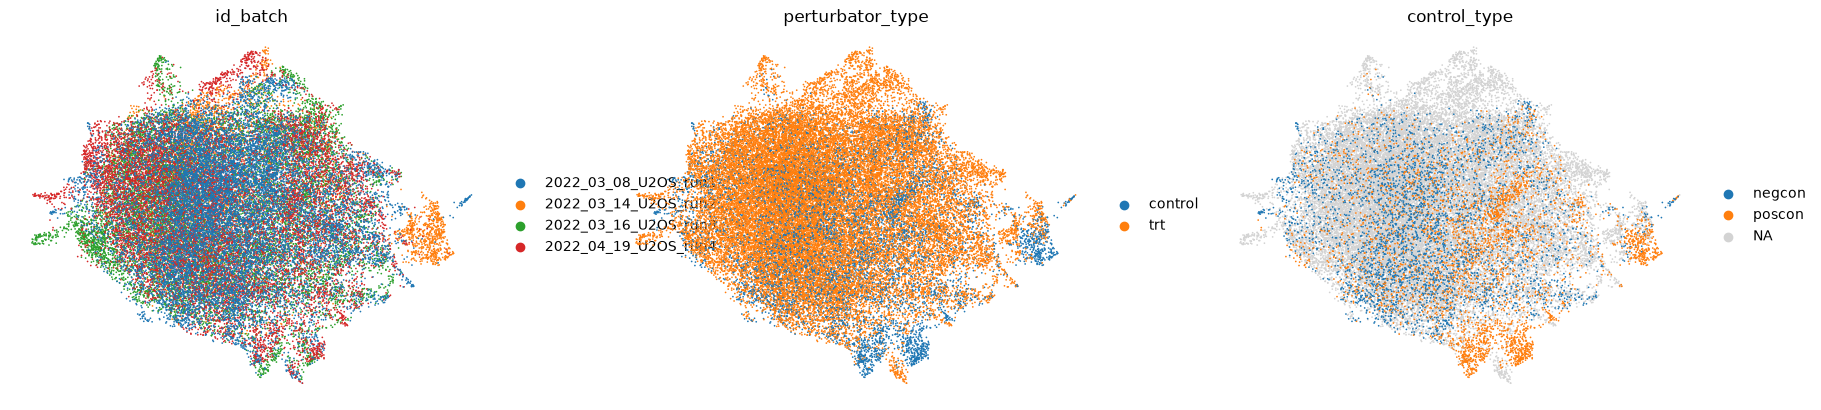

In [12]:
sc.pl.umap(adata, color=["id_batch", "perturbator_type", "control_type"], ncols=3, frameon=False, size=6)